# Neural Networks: Assignment week 5
Nea Lukumies

Assignment instructions: https://github.com/kopuj/neuralNetworks/blob/master/Assignments/Assignment_week5.md

The goal is to use a binary classifier model provided in the course material as base for an expanded model. The base model contains token and positional embedding and a multi-head attention layer. The expanded model will mimic a simplified Transformer encoder block by adding two feedforward layers (fully connected layers) and residual connections with layer normalization. 

In [42]:
import keras
from keras.datasets import imdb

max_features = 10000 # vocabulary size
max_len = 250 # words per sample 

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

# pad all samples to same length 
x_train = keras.utils.pad_sequences(x_train, maxlen=max_len, padding='post')
x_test = keras.utils.pad_sequences(x_test, maxlen=max_len, padding='post')

from sklearn.model_selection import train_test_split

X_train_small, X_val, y_train_small, y_val = train_test_split(
    x_train, y_train,
    test_size=0.2,
    random_state=42
)

c:\Users\nealu\anaconda3\envs\keras\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [43]:
word_to_index = imdb.get_word_index()
index_to_word = dict((value, key) for (key, value) in word_to_index.items())

example_review = " ".join(index_to_word.get(i-3, "?") for i in x_train[0])
print(example_review)

? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you thi

In [44]:
from keras.layers import Layer, Embedding

class TokenAndPositionEmbedding(Layer):
    def __init__(self, seq_len, vocab_size, emb_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        self.token_emb = Embedding(input_dim=vocab_size, output_dim=emb_dim)
        self.pos_emb = Embedding(input_dim=seq_len, output_dim=emb_dim)

    def call(self, x_input):
        seq_len = keras.ops.shape(x_input)[-1]
        positions = keras.ops.arange(start=0, stop=seq_len, step=1)
        positions = self.pos_emb(positions)
        x_input = self.token_emb(x_input)
        return x_input + positions

In [45]:
from keras.layers import MultiHeadAttention
from keras.layers import Input, Dense, GlobalAveragePooling1D, Dropout, LayerNormalization, Add
from keras.models import Model
embed_dim = 32 # word embeddings dimension

num_heads = 2 # number of attention heads 
key_dim = embed_dim // num_heads # query/key dimension for one head
ff_dim = 16 # hidden layer size in feed forward network inside transformer

inputs = Input(shape=(max_len,)) 

# Embedding layer with positional encoding
x = TokenAndPositionEmbedding(max_len, max_features, embed_dim)(inputs) 

# Multi-head self-attention layer
attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x) 

# Residual nr1 + Layer normalization
x1 = Add()([x, attention_output])
x1 = LayerNormalization()(x1)

# Feed forward network
ffn = Dense(ff_dim, activation='relu')(x1)
ffn = Dense(embed_dim)(ffn)

# Residual nr2 + Layer normalization
x2 = Add()([x1, ffn])
x2 = LayerNormalization()(x2)

# Pooling and classification head
x = GlobalAveragePooling1D()(x2) 
x = Dropout(0.5)(x) 
outputs = Dense(1, activation='sigmoid')(x) 

att_model = Model(inputs=inputs, outputs=outputs) 

learning_rate = 1e-4
att_model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss='binary_crossentropy', metrics=['accuracy']) 

att_model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 250)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 250, 32)   │    328,000 │ input_layer_8[0]… │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 250, 32)   │      4,224 │ token_and_positi… │
│ (MultiHeadAttentio… │                   │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 250, 32)   │          0 │ token_and_positi… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 250, 32)   │         64 │ add_13[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 250, 16)   │        528 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 250, 32)   │        544 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 250, 32)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 250, 32)   │         64 │ add_14[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 32)        │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 1)         │         33 │ dropout_17[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 333,457 (1.27 MB)

 Trainable params: 333,457 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
history = att_model.fit(
    X_train_small, y_train_small,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 37ms/step - accuracy: 0.6071 - loss: 0.6660 - val_accuracy: 0.7272 - val_loss: 0.6145
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.7785 - loss: 0.5108 - val_accuracy: 0.8574 - val_loss: 0.3653
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.8734 - loss: 0.3217 - val_accuracy: 0.8796 - val_loss: 0.2909
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.9013 - loss: 0.2575 - val_accuracy: 0.8870 - val_loss: 0.2721
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 42ms/step - accuracy: 0.9133 - loss: 0.2263 - val_accuracy: 0.8848 - val_loss: 0.2801
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.9222 - loss: 0.2037 - val_accuracy: 0.8664 - val_loss: 0.3296
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.9358 - loss: 0.1771 - val_accuracy: 0.8722 - val_loss: 0.3299
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.9367 - loss: 0.1707 - 

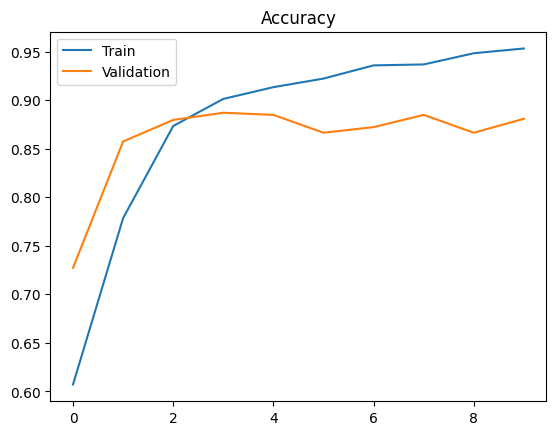

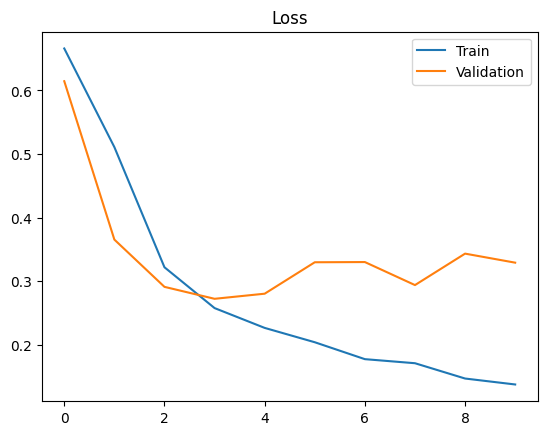

In [47]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()
plt.show()

In [48]:
test_acc = att_model.evaluate(x_test, y_test)[1]
print(f'Test accuracy = {test_acc:.4f}')

782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8674 - loss: 0.3671
Test accuracy = 0.8674


The original test accuracy for the model in the course material was 0.8741. I did not achieve better accuracies with the expanded model with the hyperparameters I tried. I added plotting of the training and validation accuracy and loss to the code to see if the models I trained were over- or underfitting and all of the models I trained were overfitting. I tried different learning rates (1e-3, 5e-4, 1e-4) and ffn dimensions (16-128)for the feedforward layers but I was not able to achieve better test accuracies than the original model. This would indicate that the nature of the IMDb dataset is such that the simple model was already able to capture the necessary features for the classification task and added complexity (transformer encoder block) did not add to the performance. This would then indicate that the residual and layer normalization connections did not help enough with how the model can generalize to the test data.

For an actual model the hyperparametrs needed is in this notebook, but the number of epochs should be set to lower as overfitting seems to start after 2 epochs. 